# Other offline learning algorithms

In [62]:
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym


import d3rlpy
from d3rlpy.datasets import get_cartpole
from d3rlpy.algos import DQNConfig, TD3Config
from d3rlpy.metrics import TDErrorEvaluator, EnvironmentEvaluator

from pmind.replay import convert_rb_to_dataset, mix_transitions
from pmind.algorithms import BBRLStyleTD3, BBRLStyleIQL

from pmind.config.loader import load_config
from omegaconf import OmegaConf

import bbrl_gymnasium

from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
ENV_NAME = (
    "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    # "LunarLanderContinuous-v3",
)[2]
MODELS_DIR = Path(f"../models/{ENV_NAME}/")


cfg = load_config("td3")
cfg = OmegaConf.create(cfg.environments[ENV_NAME])

In [64]:
BUFFER_SIZE = 200_000
PROPORTION = 0.99

MAX_STEPS = 10_000 #100_000
NB_EVAL_ENVS = 3 #10 # TODO: use it?
EVAL_INTERVAL = 1000 #100
SAVE_RB_POLICY_INTERVAL = 2_000 # TODO: use it
BATCH_SIZE = 64 #64
NN_ARCHITECTURE = [32,16] #[400,300] [32,16]
LR = 1e-3

cfg_offline = OmegaConf.create(cfg)
cfg_offline.algorithm.n_steps = MAX_STEPS
cfg_offline.algorithm.max_epochs = None

cfg_offline.actor_optimizer.lr = LR
cfg_offline.critic_optimizer.lr = LR

cfg_offline.algorithm.batch_size = BATCH_SIZE
cfg_offline.algorithm.architecture.actor_hidden_size = NN_ARCHITECTURE
cfg_offline.algorithm.architecture.critic_hidden_size = NN_ARCHITECTURE


cfg_offline.algorithm.eval_interval = EVAL_INTERVAL
cfg_offline.algorithm.nb_evals = NB_EVAL_ENVS  # nb of evaluation envs in parallel
    
cfg_offline.algorithm.save_rb_policy_interval = SAVE_RB_POLICY_INTERVAL

# learning starts immediately for offline:
cfg_offline.algorithm.learning_starts = None

# there is no exploration in offline learning
cfg_offline.algorithm.action_noise = None
# cfg_offline.algorithm.target_policy_noise = None # #TODO: correct?

In [65]:
cfg_offline

{'save_best': False, 'base_dir': '${gym_env.env_name}/td3-S${algorithm.seed}_${current_time:}', 'collect_stats': True, 'plot_agents': False, 'algorithm': {'seed': 1, 'max_grad_norm': 0.5, 'n_envs': 1, 'n_steps': 10000, 'nb_evals': 3, 'discount_factor': 0.99, 'buffer_size': 200000, 'batch_size': 64, 'tau_target': 0.05, 'eval_interval': 1000, 'max_epochs': None, 'learning_starts': None, 'action_noise': None, 'policy_delay': 2, 'target_policy_noise': 0.5, 'target_policy_noise_clip': 0.5, 'architecture': {'actor_hidden_size': [32, 16], 'critic_hidden_size': [32, 16]}, 'intermediate_rewards': [25, 50, 75, 80, 85, 90, 95, 100], 'intermediate_n_steps': [10000, 20000, 30000, 40000, 50000], 'save_rb_policy_interval': 2000}, 'gym_env': {'env_name': 'MountainCarContinuous-v0'}, 'actor_optimizer': {'classname': 'torch.optim.Adam', 'lr': 0.001}, 'critic_optimizer': {'classname': 'torch.optim.Adam', 'lr': 0.001}, 'action_scaling': 1}

we will try those algos:

```py
d3rlpy.algos.BCConfig()
d3rlpy.algos.TD3PlusBCConfig()
d3rlpy.algos.TD3Config()
d3rlpy.algos.IQLConfig()
```

Note that BC ignores the reward.

NOTE: what they call an "epoch" here is not about a pass
through the whole dataset, but just a logging checkpoint

In [66]:
# print("Available buffers:\n")
# print("\n".join([file.name for file in MODELS_DIR.glob("rb-*.pt")]))

In [67]:
rb_unif = torch.load(MODELS_DIR / "rb-unif.pt", weights_only=False)
rb_exploit = torch.load(MODELS_DIR / "rb-61.pt", weights_only=False)

dataset_unif = convert_rb_to_dataset(rb_unif, contains_teleportation=True)
dataset_exploit = convert_rb_to_dataset(rb_exploit, contains_teleportation=True)

dataset = mix_transitions(
    dataset_unif, dataset_exploit, buffer_size=BUFFER_SIZE, proportion=PROPORTION
)

2026-05-01 15:50.21 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-05-01 15:50.21 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2026-05-01 15:50.21 [info     ] Action size has been automatically determined. action_size=1
2026-05-01 15:50.21 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-05-01 15:50.21 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2026-05-01 15:50.21 [info     ] Action size has been automatically determined. action_size=1


In [68]:
print(f"Exploit transitions: {dataset_exploit.transition_count}")
print(f"Uniform transitions: {dataset_unif.transition_count}")
print(f"Mixed transitions: {dataset.transition_count}")

Exploit transitions: 200000
Uniform transitions: 200000
Mixed transitions: 400000


In [71]:
algo = BBRLStyleIQL(cfg_offline)
algo.train(dataset)

Reward at initialization: -17.924006729131847


  0%|          | 0/10 [00:00<?, ?it/s]

10000
2026-05-01 15:51.14 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-05-01 15:51.14 [warning  ] Skip building models since they're already built.
2026-05-01 15:51.14 [info     ] Directory is created at d3rlpy_logs/IQL_20260501155114
2026-05-01 15:51.14 [info     ] Parameters                     params={'observation_shape': [2], 'action_size': 1, 'config': {'type': 'iql', 'params': {'batch_size': 64, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'min_max', 'params': {'minimum': -1.0, 'maximum': 1.0}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'actor_learning_rate': 0.001, 'critic_learning_rate': 0.001, 'actor_optim_fa

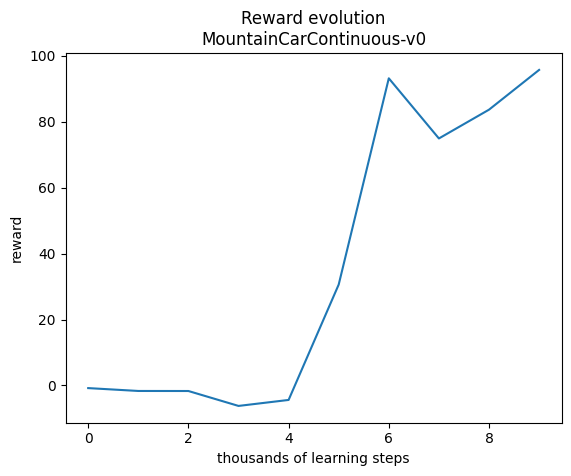

In [72]:
plt.plot(algo.eval_rewards)
plt.title(f"Reward evolution\n{ENV_NAME}")
plt.ylabel("reward")
plt.xlabel("thousands of learning steps")
plt.show()